### Comparación y evaluación de modelos

Se evaluan los modelos tuneados del notebook 02. Validamos en `Val` y `Test` como validación final.

In [15]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, fbeta_score, recall_score, precision_score,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay,
)

import warnings
warnings.filterwarnings('ignore')

BETA = 2
METRIC_NAME = f'F{BETA}'

data = joblib.load('../data/processed_data.pkl')
X_train = data['X_train']
X_val   = data['X_test']   # pkl key 'X_test' es el set de validación
X_test  = data['X_val']    # pkl key 'X_val' es el holdout final
y_train = data['y_train']
y_val   = data['y_test']
y_test  = data['y_val']

dummy_best = joblib.load('../models/dummy_classifier.pkl')
knn_best   = joblib.load('../models/knn_tuned.pkl')
dt_best    = joblib.load('../models/decision_tree_tuned.pkl')
rf_best    = joblib.load('../models/random_forest_tuned.pkl')
xgb_best   = joblib.load('../models/xgboost_tuned.pkl')
svc_best   = joblib.load('../models/svc_tuned.pkl')

print(f'X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')
print('Modelos cargados correctamente.')

X_train: (3065, 14) | X_val: (1022, 14) | X_test: (1022, 14)
Modelos cargados correctamente.


## Comparación en Validation

Veamos las métricas sobre `X_val`

In [16]:
# Decision Tree
y_prob_dt_val = dt_best.predict_proba(X_val)[:, 1]
y_pred_dt_val = dt_best.predict(X_val)

dt_metrics = {
    'Modelo':    'Decision Tree',
    'AUC-ROC':   roc_auc_score(y_val, y_prob_dt_val),
    'PR-AUC':    average_precision_score(y_val, y_prob_dt_val),
    'F1':        f1_score(y_val, y_pred_dt_val),
    METRIC_NAME: fbeta_score(y_val, y_pred_dt_val, beta=BETA),
    'Recall':    recall_score(y_val, y_pred_dt_val),
    'Precision': precision_score(y_val, y_pred_dt_val, zero_division=0),
}
print(dt_metrics)

{'Modelo': 'Decision Tree', 'AUC-ROC': 0.797716049382716, 'PR-AUC': 0.14197057717929334, 'F1': 0.23178807947019867, 'F2': 0.38716814159292035, 'Recall': 0.7, 'Precision': 0.1388888888888889}


In [17]:
# Random Forest
y_prob_rf_val = rf_best.predict_proba(X_val)[:, 1]
y_pred_rf_val = rf_best.predict(X_val)

rf_metrics = {
    'Modelo':    'Random Forest',
    'AUC-ROC':   roc_auc_score(y_val, y_prob_rf_val),
    'PR-AUC':    average_precision_score(y_val, y_prob_rf_val),
    'F1':        f1_score(y_val, y_pred_rf_val),
    METRIC_NAME: fbeta_score(y_val, y_pred_rf_val, beta=BETA),
    'Recall':    recall_score(y_val, y_pred_rf_val),
    'Precision': precision_score(y_val, y_pred_rf_val, zero_division=0),
}
print(rf_metrics)

{'Modelo': 'Random Forest', 'AUC-ROC': 0.8284773662551441, 'PR-AUC': 0.19371561428085735, 'F1': 0.24918032786885247, 'F2': 0.4175824175824176, 'Recall': 0.76, 'Precision': 0.14901960784313725}


In [18]:
# XGBoost
y_prob_xgb_val = xgb_best.predict_proba(X_val)[:, 1]
y_pred_xgb_val = xgb_best.predict(X_val)

xgb_metrics = {
    'Modelo':    'XGBoost',
    'AUC-ROC':   roc_auc_score(y_val, y_prob_xgb_val),
    'PR-AUC':    average_precision_score(y_val, y_prob_xgb_val),
    'F1':        f1_score(y_val, y_pred_xgb_val),
    METRIC_NAME: fbeta_score(y_val, y_pred_xgb_val, beta=BETA),
    'Recall':    recall_score(y_val, y_pred_xgb_val),
    'Precision': precision_score(y_val, y_pred_xgb_val, zero_division=0),
}
print(xgb_metrics)

{'Modelo': 'XGBoost', 'AUC-ROC': 0.8109053497942387, 'PR-AUC': 0.19888080760946236, 'F1': 0.21993127147766323, 'F2': 0.36281179138321995, 'Recall': 0.64, 'Precision': 0.13278008298755187}


In [19]:
# KNN
y_prob_knn_val = knn_best.predict_proba(X_val)[:, 1]
y_pred_knn_val = knn_best.predict(X_val)

knn_metrics = {
    'Modelo':    'KNN',
    'AUC-ROC':   roc_auc_score(y_val, y_prob_knn_val),
    'PR-AUC':    average_precision_score(y_val, y_prob_knn_val),
    'F1':        f1_score(y_val, y_pred_knn_val),
    METRIC_NAME: fbeta_score(y_val, y_pred_knn_val, beta=BETA),
    'Recall':    recall_score(y_val, y_pred_knn_val),
    'Precision': precision_score(y_val, y_pred_knn_val, zero_division=0),
}
print(knn_metrics)

{'Modelo': 'KNN', 'AUC-ROC': 0.5798559670781893, 'PR-AUC': 0.06104248824448711, 'F1': 0.056338028169014086, 'F2': 0.04524886877828054, 'Recall': 0.04, 'Precision': 0.09523809523809523}


In [20]:
# SVC
y_prob_svc_val = svc_best.predict_proba(X_val)[:, 1]
y_pred_svc_val = svc_best.predict(X_val)

svc_metrics = {
    'Modelo':    'SVC',
    'AUC-ROC':   roc_auc_score(y_val, y_prob_svc_val),
    'PR-AUC':    average_precision_score(y_val, y_prob_svc_val),
    'F1':        f1_score(y_val, y_pred_svc_val),
    METRIC_NAME: fbeta_score(y_val, y_pred_svc_val, beta=BETA),
    'Recall':    recall_score(y_val, y_pred_svc_val),
    'Precision': precision_score(y_val, y_pred_svc_val, zero_division=0),
}
print(svc_metrics)

{'Modelo': 'SVC', 'AUC-ROC': 0.818395061728395, 'PR-AUC': 0.18486925905738885, 'F1': 0.22038567493112948, 'F2': 0.3898635477582846, 'Recall': 0.8, 'Precision': 0.12779552715654952}


In [21]:
# Dummy Classifier
y_prob_dummy_val = dummy_best.predict_proba(X_val)[:, 1]
y_pred_dummy_val = dummy_best.predict(X_val)

dummy_metrics = {
    'Modelo':    'Dummy Classifier',
    'AUC-ROC':   roc_auc_score(y_val, y_prob_dummy_val),
    'PR-AUC':    average_precision_score(y_val, y_prob_dummy_val),
    'F1':        f1_score(y_val, y_pred_dummy_val, zero_division=0),
    METRIC_NAME: fbeta_score(y_val, y_pred_dummy_val, beta=BETA, zero_division=0),
    'Recall':    recall_score(y_val, y_pred_dummy_val, zero_division=0),
    'Precision': precision_score(y_val, y_pred_dummy_val, zero_division=0),
}
print(dummy_metrics)

{'Modelo': 'Dummy Classifier', 'AUC-ROC': 0.5, 'PR-AUC': 0.04892367906066536, 'F1': 0.0, 'F2': 0.0, 'Recall': 0.0, 'Precision': 0.0}


In [22]:
val_df = (
    pd.DataFrame([
        dummy_metrics,
        knn_metrics, dt_metrics, rf_metrics, xgb_metrics, svc_metrics,
    ])
    .set_index('Modelo')
    .sort_values(METRIC_NAME, ascending=False)
)
display(val_df.style.highlight_max(axis=0).format('{:.4f}'))

best_model_name = val_df[METRIC_NAME].idxmax()
print(f'\nMejor modelo por {METRIC_NAME} en validation: {best_model_name} '
      f'({METRIC_NAME}={val_df.loc[best_model_name, METRIC_NAME]:.4f}, '
      f'Recall={val_df.loc[best_model_name, "Recall"]:.4f})')

,AUC-ROC,PR-AUC,F1,F2,Recall,Precision
Modelo,,,,,,
Random Forest,0.8285,0.1937,0.2492,0.4176,0.7600,0.1490
SVC,0.8184,0.1849,0.2204,0.3899,0.8000,0.1278
Decision Tree,0.7977,0.1420,0.2318,0.3872,0.7000,0.1389
XGBoost,0.8109,0.1989,0.2199,0.3628,0.6400,0.1328
KNN,0.5799,0.0610,0.0563,0.0452,0.0400,0.0952
Dummy Classifier,0.5000,0.0489,0.0000,0.0000,0.0000,0.0000



Mejor modelo por F2 en validation: Random Forest (F2=0.4176, Recall=0.7600)


## Curvas ROC y Precision-Recall (Validation Set)

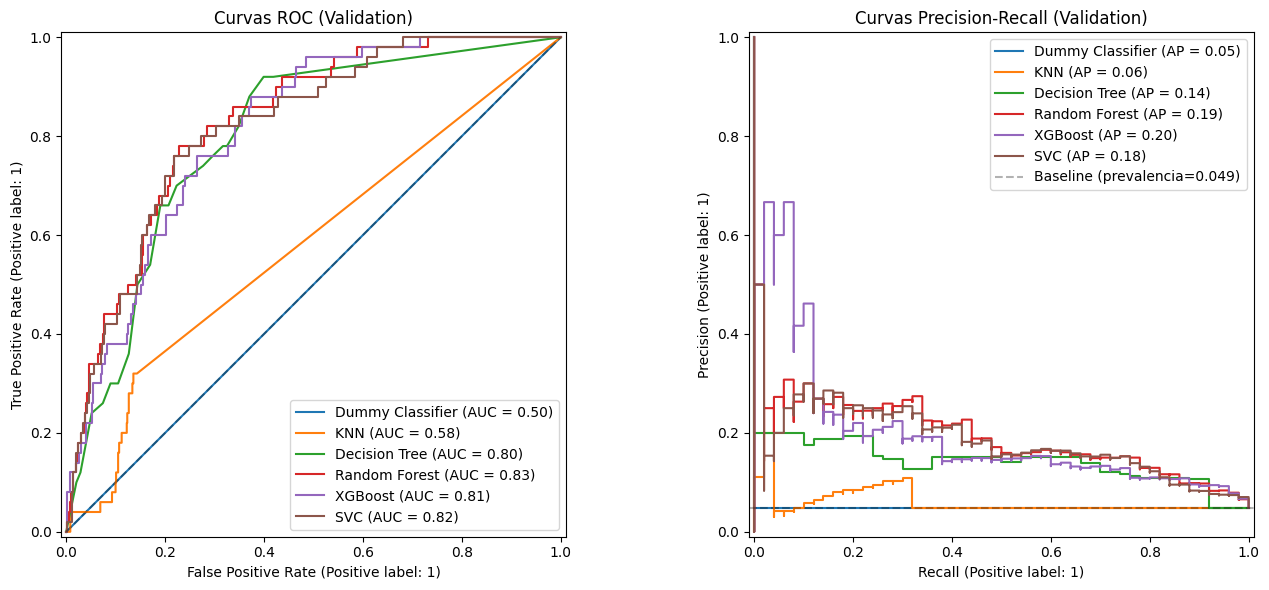

In [23]:
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 6))

# ROC
RocCurveDisplay.from_predictions(y_val, y_prob_dummy_val, name='Dummy Classifier', ax=ax_roc)
RocCurveDisplay.from_predictions(y_val, y_prob_knn_val,   name='KNN',              ax=ax_roc)
RocCurveDisplay.from_predictions(y_val, y_prob_dt_val,    name='Decision Tree',    ax=ax_roc)
RocCurveDisplay.from_predictions(y_val, y_prob_rf_val,    name='Random Forest',    ax=ax_roc)
RocCurveDisplay.from_predictions(y_val, y_prob_xgb_val,   name='XGBoost',          ax=ax_roc)
RocCurveDisplay.from_predictions(y_val, y_prob_svc_val,   name='SVC',              ax=ax_roc)
ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax_roc.set_title('Curvas ROC (Validation)')

# Precision-Recall
PrecisionRecallDisplay.from_predictions(y_val, y_prob_dummy_val, name='Dummy Classifier', ax=ax_pr)
PrecisionRecallDisplay.from_predictions(y_val, y_prob_knn_val,   name='KNN',              ax=ax_pr)
PrecisionRecallDisplay.from_predictions(y_val, y_prob_dt_val,    name='Decision Tree',    ax=ax_pr)
PrecisionRecallDisplay.from_predictions(y_val, y_prob_rf_val,    name='Random Forest',    ax=ax_pr)
PrecisionRecallDisplay.from_predictions(y_val, y_prob_xgb_val,   name='XGBoost',          ax=ax_pr)
PrecisionRecallDisplay.from_predictions(y_val, y_prob_svc_val,   name='SVC',              ax=ax_pr)
prevalence = y_val.mean() if hasattr(y_val, 'mean') else np.mean(y_val)
ax_pr.axhline(prevalence, color='k', linestyle='--', alpha=0.3,
              label=f'Baseline (prevalencia={prevalence:.3f})')
ax_pr.legend(loc='upper right')
ax_pr.set_title('Curvas Precision-Recall (Validation)')

plt.tight_layout()
plt.show()

## Matrices de Confusión en Validation

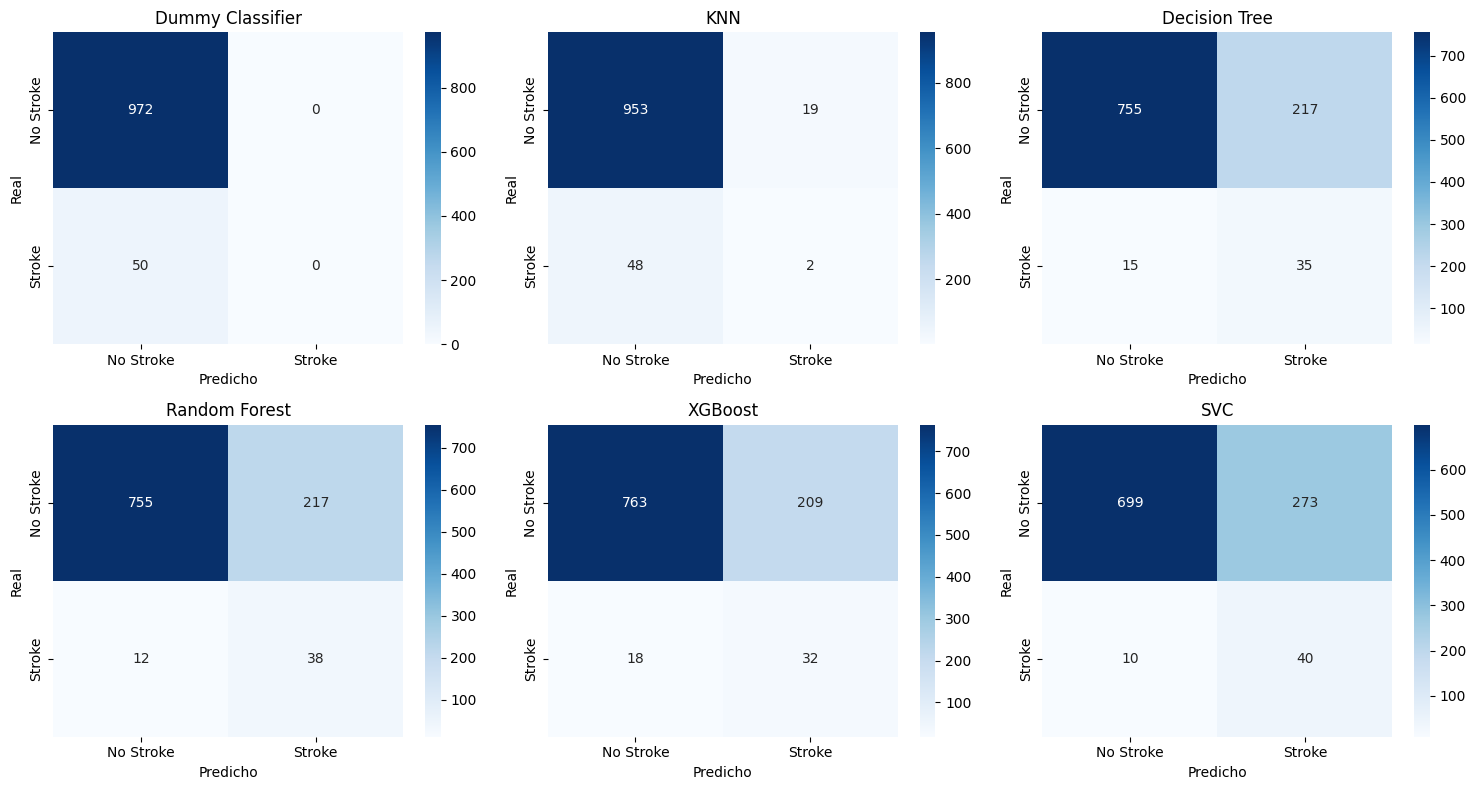

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (y_pred, title) in zip(axes, [
    (y_pred_dummy_val, 'Dummy Classifier'),
    (y_pred_knn_val,   'KNN'),
    (y_pred_dt_val,    'Decision Tree'),
    (y_pred_rf_val,    'Random Forest'),
    (y_pred_xgb_val,   'XGBoost'),
    (y_pred_svc_val,   'SVC'),
]):
    sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Stroke', 'Stroke'],
                yticklabels=['No Stroke', 'Stroke'])
    ax.set_title(title)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

A simple vista, Decision Tree, Random Forest, XGBoost y SVC muestran un desempeño similar: los F2 en CV oscilan entre 0.40 y 0.42, con diferencias menores a 0.02 puntos.

Random Forest es el ganador por F2 en validation (0.4176), con un balance razonable entre recall (0.76) y precisión (0.149). La diferencia respecto a Decision Tree (F2=0.39) no es radical, lo que sugiere que un árbol simple ya captura bien la estructura del problema sin necesidad de ensambles.

SVC tiene el recall más alto (0.80) pero la precisión más baja, generando más falsos positivos. XGBoost tiene el recall más bajo de los cuatro (0.64), es decir, se pierde más casos reales de stroke (falsos negativos), aunque en términos absolutos la diferencia es pequeña dado el tamaño reducido de la clase positiva.

A pesar de que Decision Trees y Random Forest son casi iguales, se elige el modelo que menores falsos negativos tiene. En validation solo es una diferencia de 3 falsos negativos, pero estamos hablando de 3 vidas humanas.

### Modelo elegido: Random Forest

## Evaluación final en Test Set

Veamos el performance en el set de test (holdout intocado)

In [25]:
best_models = {
    'Dummy Classifier': dummy_best,
    'KNN':              knn_best,
    'Decision Tree':    dt_best,
    'Random Forest':    rf_best,
    'XGBoost':          xgb_best,
    'SVC':              svc_best,
}
best_model = best_models[best_model_name]

y_prob_test = best_model.predict_proba(X_test)[:, 1]
y_pred_test = best_model.predict(X_test)

test_metrics = {
    'Modelo':    best_model_name,
    'AUC-ROC':   roc_auc_score(y_test, y_prob_test),
    'PR-AUC':    average_precision_score(y_test, y_prob_test),
    'F1':        f1_score(y_test, y_pred_test, zero_division=0),
    METRIC_NAME: fbeta_score(y_test, y_pred_test, beta=BETA, zero_division=0),
    'Recall':    recall_score(y_test, y_pred_test, zero_division=0),
    'Precision': precision_score(y_test, y_pred_test, zero_division=0),
}
test_df = pd.DataFrame([test_metrics]).set_index('Modelo')
display(test_df.style.format('{:.4f}'))

# Comparativa val vs test para detectar overfitting a val durante la selección
comparison = pd.DataFrame({
    'Val (selección)':    val_df.loc[best_model_name],
    'Test (holdout final)': test_df.loc[best_model_name],
})
print('\nComparativa métricas del ganador en Val vs Test:')
display(comparison.style.format('{:.4f}'))

,AUC-ROC,PR-AUC,F1,F2,Recall,Precision
Modelo,,,,,,
Random Forest,0.8071,0.2589,0.2458,0.4102,0.7400,0.1474



Comparativa métricas del ganador en Val vs Test:


,Val (selección),Test (holdout final)
AUC-ROC,0.8285,0.8071
PR-AUC,0.1937,0.2589
F1,0.2492,0.2458
F2,0.4176,0.4102
Recall,0.7600,0.7400
Precision,0.1490,0.1474


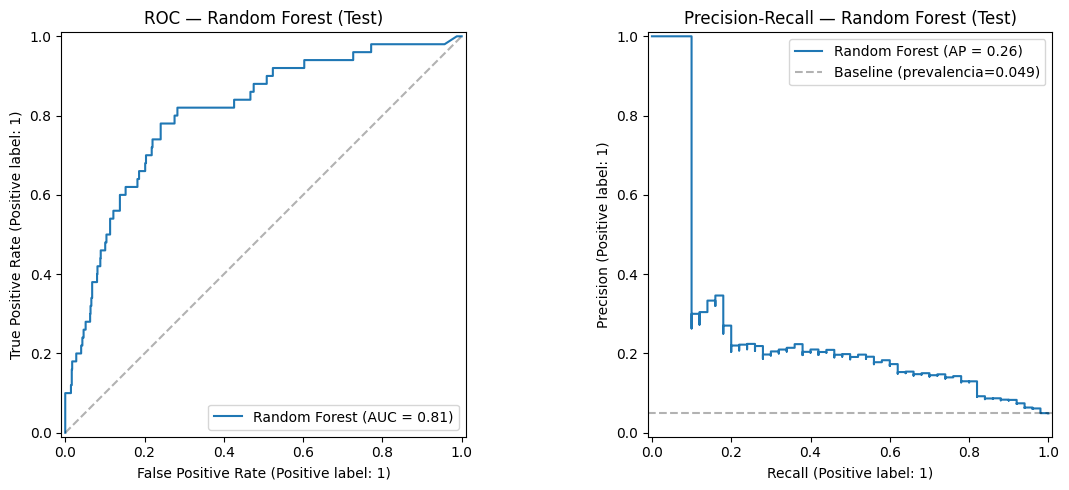

In [26]:
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, y_prob_test, name=best_model_name, ax=ax_roc)
ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax_roc.set_title(f'ROC — {best_model_name} (Test)')

PrecisionRecallDisplay.from_predictions(y_test, y_prob_test, name=best_model_name, ax=ax_pr)
prevalence_test = y_test.mean() if hasattr(y_test, 'mean') else np.mean(y_test)
ax_pr.axhline(prevalence_test, color='k', linestyle='--', alpha=0.3,
              label=f'Baseline (prevalencia={prevalence_test:.3f})')
ax_pr.legend(loc='upper right')
ax_pr.set_title(f'Precision-Recall — {best_model_name} (Test)')

plt.tight_layout()
plt.show()

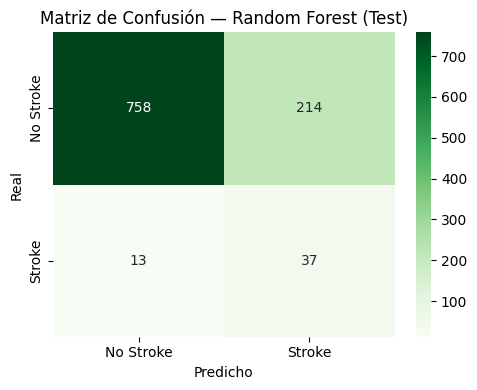

In [27]:
cm_test = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
plt.title(f'Matriz de Confusión — {best_model_name} (Test)')
plt.xlabel('Predicho'); plt.ylabel('Real')
plt.tight_layout()
plt.show()

Vemos que Random Forest es consistente testeandolo con datos nunca antes vistos.

## Guardado de los modelos

Guardamos los 5 modelos tuneados y un `.pkl` con `best_params`, F-beta en CV, `test_results` (5 modelos sobre X_test) y `val_results` (ganador sobre X_val).

In [28]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(dummy_best, '../models/dummy_classifier.pkl')
joblib.dump(knn_best,   '../models/knn_tuned.pkl')
joblib.dump(dt_best,    '../models/decision_tree_tuned.pkl')
joblib.dump(rf_best,    '../models/random_forest_tuned.pkl')
joblib.dump(xgb_best,   '../models/xgboost_tuned.pkl')
joblib.dump(svc_best,   '../models/svc_tuned.pkl')
print('Modelos guardados en ../models/')

feature_names = list(X_train.columns) if hasattr(X_train, 'columns') else None

# Preservar best_params y cv_best_fbeta guardados por el notebook de entrenamiento
_tuning_path = '../data/tuning_results.pkl'
_prev = joblib.load(_tuning_path) if os.path.exists(_tuning_path) else {}

joblib.dump({
    **_prev,
    'beta':            BETA,
    'metric_name':     METRIC_NAME,
    'val_results':     val_df,
    'test_results':    test_df,
    'best_model_name': best_model_name,
    'feature_names':   feature_names,
}, _tuning_path)

print(f'\nResumen guardado en {_tuning_path}')
print(f'Mejor modelo por {METRIC_NAME} en validation: {best_model_name} -> '
      f'{METRIC_NAME}(val)={val_df.loc[best_model_name, METRIC_NAME]:.4f} | '
      f'{METRIC_NAME}(test)={test_df.loc[best_model_name, METRIC_NAME]:.4f}')

Modelos guardados en ../models/

Resumen guardado en ../data/tuning_results.pkl
Mejor modelo por F2 en validation: Random Forest -> F2(val)=0.4176 | F2(test)=0.4102
